<div class="alert alert-block alert-info" >
    <h1 style="text-align:center;font-weight: 20px; color:black;"> Titanic  생존자 예측 - EDA</h1>
</div>

## Titanic 생존자 예측 경진대회 개요 
- **목표** 
 - 본 Kaggle Competition은 생존유무가 포함된 타이타닉 탑승객의 학습 데이터 정보를 분석하고, 그 정보를 바탕으로 머신러닝을 진행하여 테스트 데이터의 탑승객 생존유무를 예측함. 
- **배경지식**
 - 타이타닉호는 1912년 4월 10일 영국의 사우스햄프턴을 떠나 미국의 뉴욕으로 향하던 첫 항해 중에 4월 15일 빙산과 충돌하여 침몰하였다. 타이타닉호의 침몰로 1,514명이 사망하였음.

- **Competition Home**: https://softeer.ai/practice?type=DA&page=0

### [Data Files]
- train.csv: 학습용 데이터 (Features, Target) - 891건 
- test.csv:  예측용 데이터 (Features) - 418건
- sample_submission.csv: 제출용 파일

### [Features]
 - Name: 탑승객 이름
 - pclass: Ticket class (티켓클래스) 1= 1st, 2=2nd, 3=3rd
 - Sex: 성별 male, female
 - Age: 나이(세)
 - sibsp: # of siblings/spouses aboard the Titanic(함께 탑승한 형재자매, 배우자 수 총합) 
 - parch: # of parents/children aboard the Titanic(함께 탑승한 부모, 자녀 수 총합)
 - ticket: Ticket Nubmer(티켓 넘버)
 - Fare: 승객운임
 - cabin: Cabin Number(객실 넘버)
 - embarked: Port of Embarkatation (탑승항구) 
   - C = Cherbourg, Q= Queenstown, S=Southampton 

 
 
### [Target]
 - Survived (생존유무): 0 = 사망, 1= 생존
### [하이퍼 파라미터]  
    'learning_rate': [0.05, 0.1, 0.14],  #default: 0.1
    'n_estimator': [100,200, 300]}          #default: 100
### [평가 지표]
- accuracy

## 분석 단계 
- **[step1] 라이브러리 및 데이터 불러오기** 
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인 등 
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수 시각화 
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature 삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋만 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계** 
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가
 - (4) 하이퍼 파라미터 튜닝
- **[step5] 모델 선택 및 적용**
 -  test data의 예측값 생성
- **[step6] 결과 파일 생성** 
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

## [Step1] 불러오기
### (1) 라이브러리 불러오기

## 1. Library import & Data load

### 1-1)  Library import

In [1]:
## 데이터 분석을 위한 기본 필수 라이브러리 
import numpy as np 
import pandas as pd 

In [2]:
#시각화를 위한 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings as wn
wn.filterwarnings('ignore')

In [3]:
#사용할 분류모델 불러오기 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
#train & test dataset 분리
from sklearn.model_selection import train_test_split

# accuracy_score 호출 
from sklearn.metrics import accuracy_score

# hyperparameter tuning 
from sklearn.model_selection import GridSearchCV

### 1-2)  Data file load

In [5]:
#train data set 불러오기 
train = pd.read_csv('./data/train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
#test data set 불러오기 
test = pd.read_csv('./data/test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
# train dataset  정보 확인 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- 891개 데이터, 12개의 열로 이루어진 데이터프레임 
- Target : Survived (질적변수)
- Feature 중 Pclass,  Sex, Embarked 는 질적 변수임 (원핫인코딩 필요)
- 나머지 Feature는 모두 연속형 변수
- null이 있는 변수 체크: Age, Cabin, Embarked
- Ticket/Cabin의 경우 사용여부 판단필요 

In [8]:
# test dataset  정보 확인 
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


- 418개 데이터, 11개의 열로 이루어진 데이터프레임 
- null이 있는 변수 체크: Age, Fare, Cabin
- 그외 feature는 train 셋과 유사한 이슈 

## [Step2] 탐색적 데이터 분석 (EDA)
### (1)기술적 통계분석

In [9]:
#기초 통계량 확인 - train dataset  
train.describe() 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
#참고 - object에 대한 기초통계량
train.describe(include = 'O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [11]:
#기초 통계량 확인 - test dataset  
test.describe() 

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### (2) 변수별 분포 시각화 

### (1) pairplot 
- hue를 사용하여 target별로 구분해봄

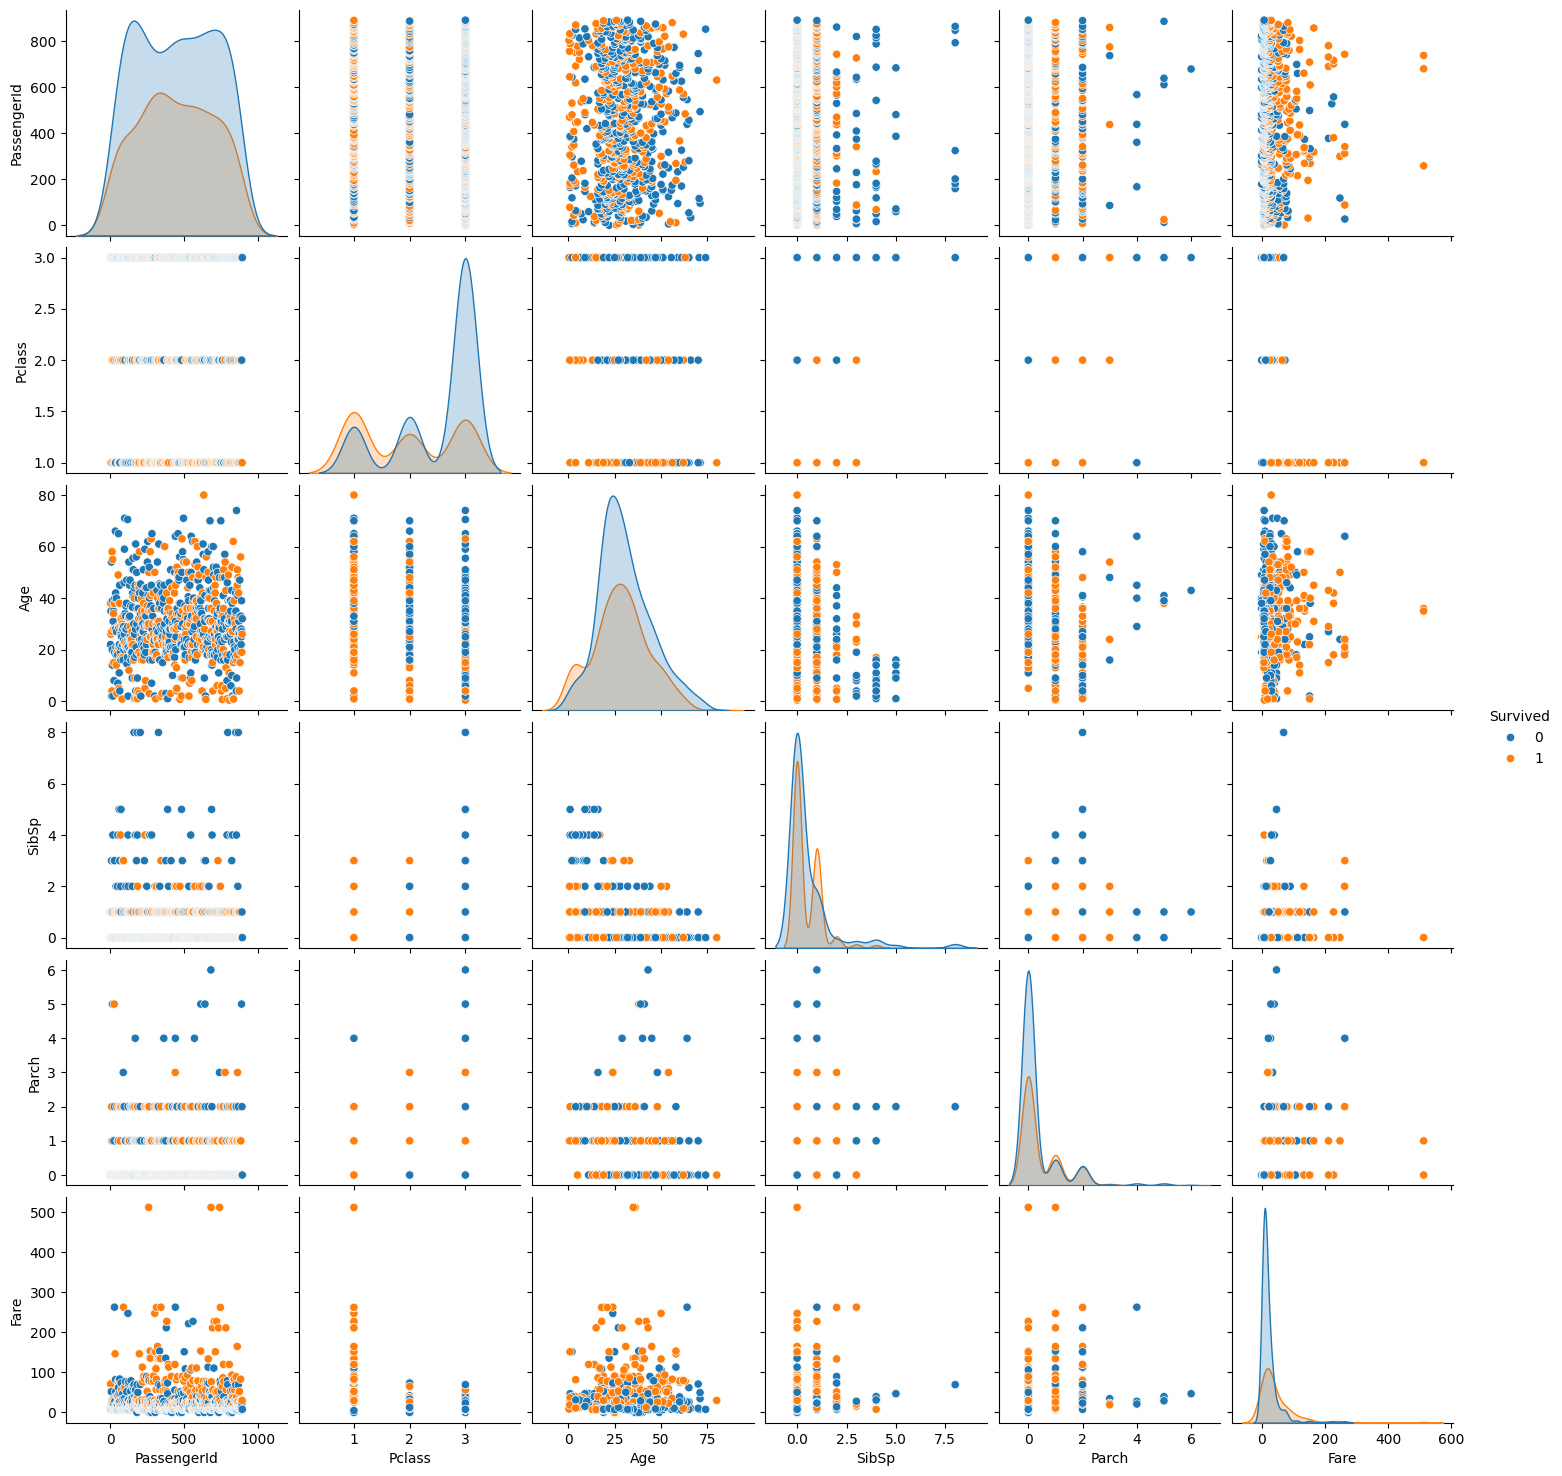

In [12]:
sns.pairplot(data=train, hue = 'Survived')

#### (2) 연속형(양적) 변수의 분포 확인 
- Age, SibSp, Parch,Fare
- histogram을 통해 분포 파악

- 빈도분석 
 - 대상 피쳐: Survived, Sex, Pclass, Embarked
 - **seaborn의 countplot()** 사용 

<Axes: xlabel='Fare', ylabel='Count'>

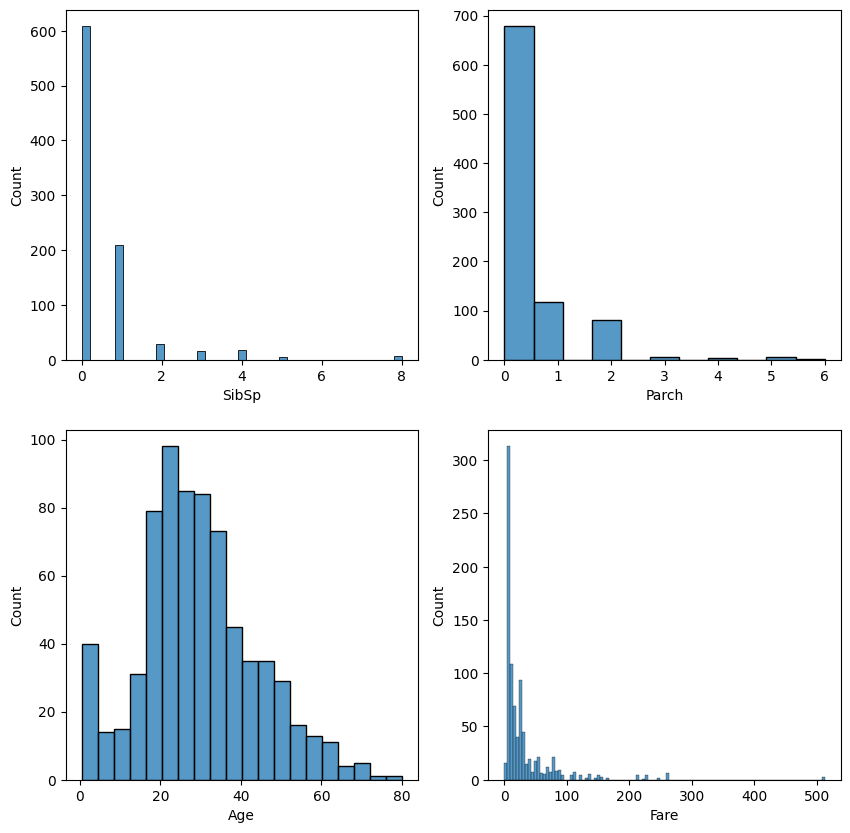

In [13]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
sns.histplot(train['SibSp'], ax=axes[0][0])
sns.histplot(train['Parch'], ax=axes[0][1])
sns.histplot(train['Age'], ax=axes[1][0])
sns.histplot(train['Fare'], ax=axes[1][1])

- Skewed된 변수 확인 - Age, SibSp, Parch, Fare
- 4변수 모두 MinMax scaling
- Fare에서 500이 넘는 값은 아웃라이어로 볼 수 있으므로 이를 제거할 것임. 

#### (3) 범주형 (질적)변수 분포 확인

<Axes: xlabel='Embarked', ylabel='count'>

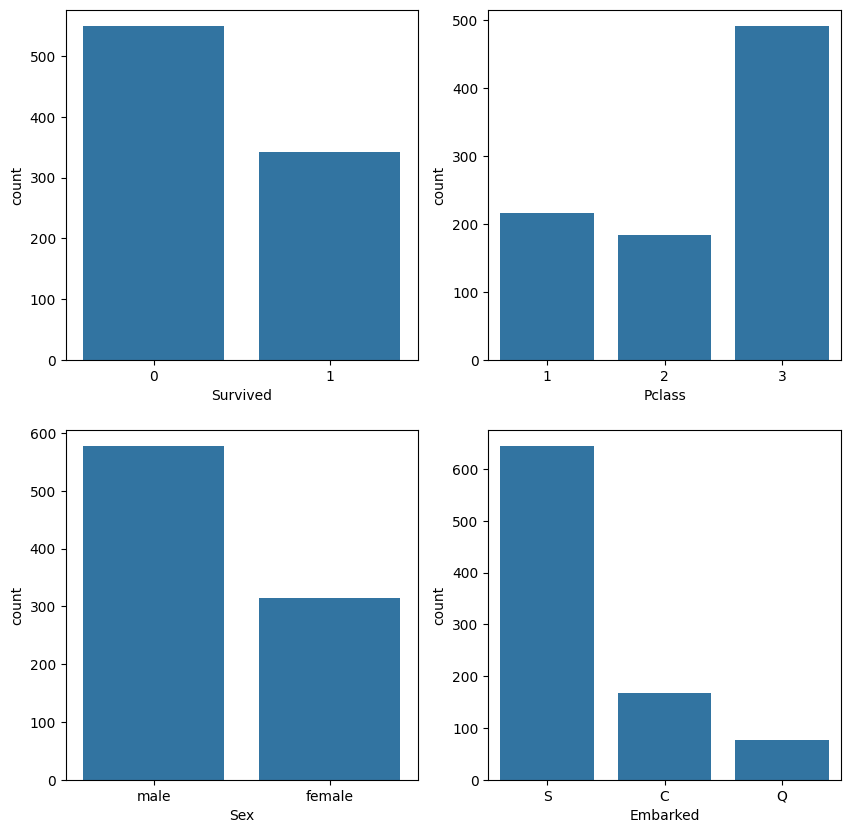

In [14]:
fig, axs =plt.subplots(2,2, figsize=(10,10))
sns.countplot( x='Survived', data=train, ax=axs[0][0])  #Target
sns.countplot( x='Pclass', data=train, ax=axs[0][1])
sns.countplot( x='Sex', data=train, ax=axs[1][0])
sns.countplot( x='Embarked',data=train, ax=axs[1][1])

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [15]:
# train 셋의 중복값 확인
train.duplicated().sum()

0


- test test는 결과 제출을 위해 중복값 처리를 하지 않음
    - sample_submission.csv에 있는 건수와 예측건수가 동일해야 하기 때문임

### (2) 불필요한 Feature 삭제

- 'PassengerId', 'Name', 'Ticket', 'Cabin'

In [16]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [17]:
drop_col = ['PassengerId', 'Name', 'Ticket', 'Cabin'] 

train.drop(drop_col, axis=1, inplace = True)
test.drop(drop_col, axis=1, inplace = True)

In [18]:
print(train.shape)
print(test.shape)

(891, 8)
(418, 7)


### (3) 결측치 처리  **(Train셋을 기준값으로)**
- train셋과 test셋에 있는 결측치 변수가 서로 다르므로 주의!
- 양적변수의 결측: 일반적으로 평균값으로 대체
- 질적변수의 결측: 일반적으로 최빈값으로 대체
#### (3)-1 train 셋

In [19]:
train.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

- Age (양적변수): 결측치를 평균값으로 대체

In [20]:
train['Age'].fillna(train['Age'].mean(), inplace=True)
# train['Age'] = train['Age'].fillna(train['Age'].mean())

In [21]:
train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

- Embarekd (질적변수): 결측치를 최빈값으로 대체
  - 방법1) value_counts()를 통해 최빈값을 직접확인하여 입력

In [22]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [23]:
train['Embarked'].fillna('S')

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

- Embarekd (질적변수): 결측치를 최빈값으로 대체 (cont.)
  - 방법2) mode()함수를 이용하여 입력

In [24]:
t=train['Embarked'].mode()
t

0    S
Name: Embarked, dtype: object

In [25]:
type(t)

pandas.core.series.Series

In [26]:
m=train['Embarked'].mode()[0]
m

'S'

In [27]:
#train dataset의 Embarked 결측치 - 가장 빈번하게 출현하는 'S' 입력 
train['Embarked'].fillna(m, inplace=True)

In [28]:
#train dataset의 결측치 제거 확인하기  
train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

#### (3)-2 test 셋

In [29]:
#결측치(null)  확인 - test dataset
test.isnull().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

- Age, Fare(양적변수): 결측치를 **train 셋의 평균값**으로 치환

In [30]:
#Age 결측치 - train dataset의 Age 평균값 입력 
test['Age'].fillna(train['Age'].mean(), inplace=True)

#Fare 결측치 - train dataset의 Fare 평균값 입력
test['Fare'].fillna(train['Fare'].mean(), inplace=True)

In [31]:
#test dataset의 결측치 제거 확인하기  
test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**

- 분류문제이므로 Target은 아웃라이어를 핸들할 필요가 없음
- Feature 중 양적변수만 아웃라이어 체크!
- 여기서는 Fare값이 450을 넘는 경우 아웃라이어로 간주 
  - 데이터 건수가 너무 적기 때문에 삭제하는 것보다는 **안쪽 범위의 가장 큰값으로 대체**할 것임

<Axes: xlabel='Fare', ylabel='Count'>

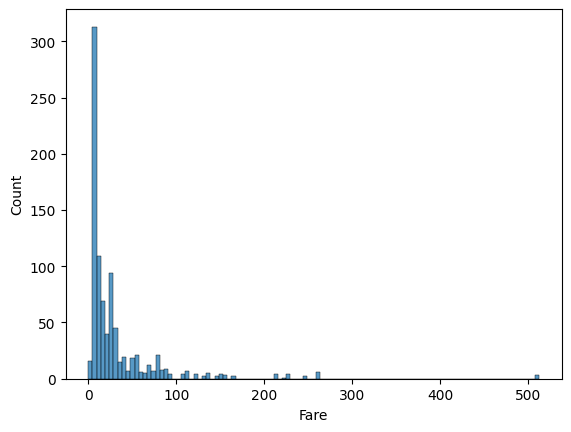

In [32]:
#fare - histplot
sns.histplot(data=train, x='Fare')

<Axes: ylabel='Fare'>

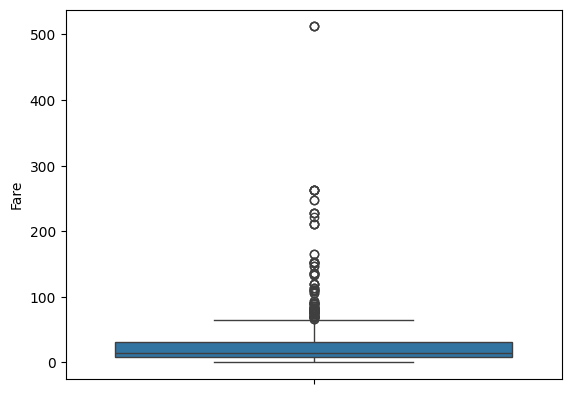

In [34]:
#fare - boxplot
sns.boxplot(data=train, y='Fare')

In [35]:
train.loc[(train['Fare']>450),['Fare']]

,Fare
258,512.3292
679,512.3292
737,512.3292


In [36]:
#안쪽범위 (450보다 적은)에서 가장 큰 값 찾기
train.loc[(train['Fare']<450),['Fare']].max()

Fare    263.0
dtype: float64

In [37]:
#450보다 큰 값들은 모두 263으로 대체
train.loc[(train['Fare']>450),['Fare']] = 263

In [38]:
#Fare max값이 263인지 확인
train['Fare'].describe()

count    891.000000
mean      31.364716
std       43.257927
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      263.000000
Name: Fare, dtype: float64

### (5) Feature, Target 설정

In [39]:
Xtrain = train.drop(['Survived'], axis=1)
Xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,3,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,3,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


In [40]:
ytrain = train['Survived']
ytrain

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [41]:
Xtest = test.copy()
Xtest

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.500000,0,0,7.8292,Q
1,3,female,47.000000,1,0,7.0000,S
2,2,male,62.000000,0,0,9.6875,Q
3,3,male,27.000000,0,0,8.6625,S
4,3,female,22.000000,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,29.699118,0,0,8.0500,S
414,1,female,39.000000,0,0,108.9000,C
415,3,male,38.500000,0,0,7.2500,S
416,3,male,29.699118,0,0,8.0500,S


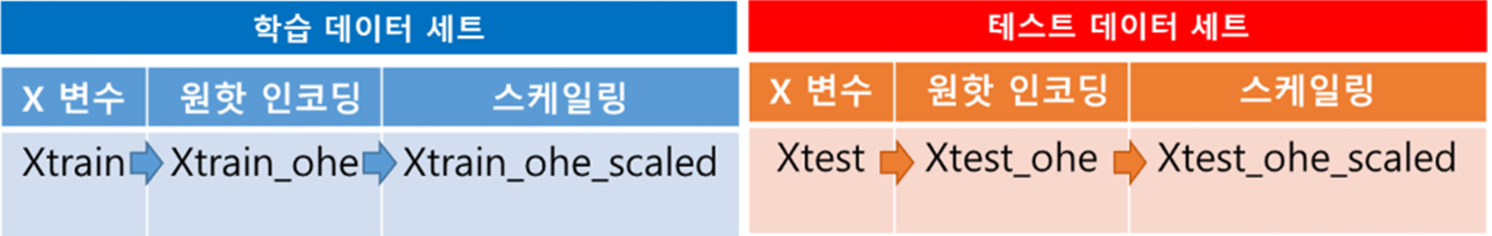

### (6) 원-핫 인코딩 **(feature-질적변수만)**

- get_dummies(df, columns=[해당 column명])
- **feature** 중 **카테고리 변수**에 대해서 수행
  - Pclass,  Sex, Embarked

In [42]:
# train 셋

Xtrain_ohe = pd.get_dummies(Xtrain, columns=['Pclass','Sex', 'Embarked'])
Xtrain_ohe

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.000000,1,0,7.2500,False,False,True,False,True,False,False,True
1,38.000000,1,0,71.2833,True,False,False,True,False,True,False,False
2,26.000000,0,0,7.9250,False,False,True,True,False,False,False,True
3,35.000000,1,0,53.1000,True,False,False,True,False,False,False,True
4,35.000000,0,0,8.0500,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.000000,0,0,13.0000,False,True,False,False,True,False,False,True
887,19.000000,0,0,30.0000,True,False,False,True,False,False,False,True
888,29.699118,1,2,23.4500,False,False,True,True,False,False,False,True
889,26.000000,0,0,30.0000,True,False,False,False,True,True,False,False


In [43]:
# test data 대상으로 one-hot encoding 및 확인 

Xtest_ohe = pd.get_dummies(Xtest, columns=['Pclass','Sex', 'Embarked'])
Xtest_ohe

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,34.500000,0,0,7.8292,False,False,True,False,True,False,True,False
1,47.000000,1,0,7.0000,False,False,True,True,False,False,False,True
2,62.000000,0,0,9.6875,False,True,False,False,True,False,True,False
3,27.000000,0,0,8.6625,False,False,True,False,True,False,False,True
4,22.000000,1,1,12.2875,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
413,29.699118,0,0,8.0500,False,False,True,False,True,False,False,True
414,39.000000,0,0,108.9000,True,False,False,True,False,True,False,False
415,38.500000,0,0,7.2500,False,False,True,False,True,False,False,True
416,29.699118,0,0,8.0500,False,False,True,False,True,False,False,True


### (7) 스케일링 **(feature-양적변수만)**

- MinMaxScaling을 이용하여 스케일링을 실시함.

In [44]:
from sklearn.preprocessing import MinMaxScaler

#object 선언
minmax_scaler = MinMaxScaler()

In [45]:
#scaling된 xtrain을 별도 생성
Xtrain_ohe_scaled = Xtrain_ohe.copy()

# StandardScaling
Xtrain_ohe_scaled[['SibSp','Parch','Fare','Age']] \
  = minmax_scaler.fit_transform(Xtrain_ohe[['SibSp','Parch','Fare','Age']])

- [주의] 테스트 데이터에는 transform만 적용

In [46]:
Xtest_ohe_scaled = Xtest_ohe.copy()

# StandardScaling
Xtest_ohe_scaled[['SibSp','Parch','Fare','Age']] \
    = minmax_scaler.transform(Xtest_ohe[['SibSp','Parch','Fare','Age']])

## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
    - LogisticRregression, DecisionTreeClassifier, KNeighborsClassifier
    - 앙상블 모델 
     - (배깅 기법)RandomForestClassifier, ExtraTreesClassifier,  
     - (부스팅 기법)XGBClassifier, LGBMClassifier

### (1) 훈련 및 검증 데이터 분할

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 0

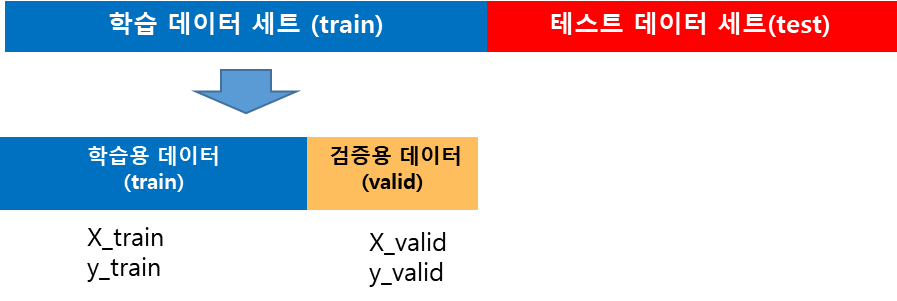

- single validation 할 때

In [47]:
# 데이터 분할: test_size=0.2, random_state=0
X_train, X_val, y_train, y_val = train_test_split(Xtrain_ohe_scaled,
                                                  ytrain,
                                                  test_size=0.2, 
                                                  random_state=0)  

In [48]:
### (2) 알고리즘별 학습, 예측, 평가 

# for문을 이용하여 작성
# 1) Logistic Regression ~ 6) LGBM Regressor

models = {    
    'LogisticRegression': LogisticRegression(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Random Forest Classifier': RandomForestClassifier(n_jobs=-1),
    'Extra Trees Classifier': ExtraTreesClassifier(n_jobs=-1),
    'XGB Classifier' : XGBClassifier(verbose=-1,n_jobs=-1),
    'LGBM Classifier' : LGBMClassifier(verbose=-1,n_jobs=-1)
}

# 초기화: selected_estimator, max_score
selected_estimator = None
max_score = 0

# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    score = accuracy_score(y_val, pred)
    print(f'[{name} 모델의 accuracy ]: {round(score, 3)}')

    if score > max_score:
        selected_estimator = estimator
        max_score = score
        print(f'selected estimator: {name}')
    print('')

[LogisticRegression 모델의 accuracy ]: 0.799
selected estimator: LogisticRegression

[Decision Tree Classifier 모델의 accuracy ]: 0.765

[KNN 모델의 accuracy ]: 0.81
selected estimator: KNN

[Random Forest Classifier 모델의 accuracy ]: 0.81

[Extra Trees Classifier 모델의 accuracy ]: 0.816
selected estimator: Extra Trees Classifier

[XGB Classifier 모델의 accuracy ]: 0.838
selected estimator: XGB Classifier

[LGBM Classifier 모델의 accuracy ]: 0.855
selected estimator: LGBM Classifier



In [49]:
selected_estimator

LGBMClassifier(n_jobs=-1, verbose=-1)

#### 6) 성능 개선을 위한 하이퍼 파라미터 튜닝 

- default parameter일때의 성능을 Cross Validation 기반 재검증

In [50]:
# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters ={}

# 2) GridSearchCV 설정: 
grid_clf = GridSearchCV(selected_estimator, parameters,cv=5,
                           scoring='accuracy')

# 3) GridSearchCV estimator로 학습: 
grid_clf.fit(Xtrain_ohe_scaled, ytrain)

# 4) Score확인
print('최적 하이퍼 파라미터 score: ', grid_clf.best_score_)

최적 하이퍼 파라미터 score:  0.8238152030632101


In [51]:
# 1) 파라미터 후보군 설정- 많은 하이퍼파라미터를 대상으로 진행할 수 있지만, 시간 관계상 일부만 시도
parameters ={        
    'learning_rate': [0.05, 0.1, 0.14],  #default: 0.1
    'n_estimator': [100,200, 300]}          #default: 100

In [52]:
# 2) GridSearchCV 설정: 

grid_clf = GridSearchCV(selected_estimator, 
                        parameters,
                        cv=5,
                        scoring='accuracy') 

In [53]:
# 3) GridSearchCV estimator로 학습: 
grid_clf.fit(Xtrain_ohe_scaled, ytrain)

GridSearchCV(cv=5, estimator=LGBMClassifier(n_jobs=-1, verbose=-1),
             param_grid={'learning_rate': [0.05, 0.1, 0.14],
                         'n_estimator': [100, 200, 300]},
             scoring='accuracy')

In [54]:
# 4) GridSearchCV 결과 확인
print('최적 하이퍼 파라미터 : ', grid_clf.best_params_ )

최적 하이퍼 파라미터 :  {'learning_rate': 0.05, 'n_estimator': 100}


In [55]:
# 5) GridSearchCV score 확인
print('최적 하이퍼 파라미터 score: ', grid_clf.best_score_)

최적 하이퍼 파라미터 score:  0.839539263071998


In [56]:
grid_clf.best_estimator_

LGBMClassifier(learning_rate=0.05, n_estimator=100, n_jobs=-1, verbose=-1)

## [step5] 모델 선택 및 적용
 - test data의 예측값 생성

 - 높은 성능의 모델 선택 후 test data의 예측값 생성 

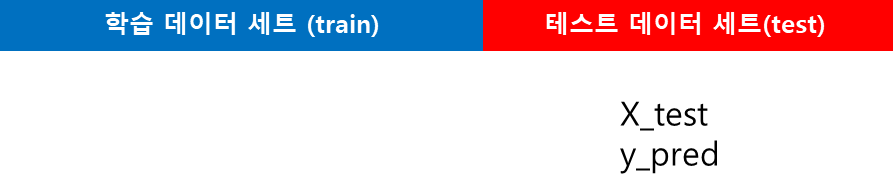

In [57]:
# 하이터파라미터 튜닝된 estimator로 test 셋의 target 예측

pred_test = grid_clf.best_estimator_.predict(Xtest_ohe_scaled)

In [58]:
pred_test

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

- 실제값과 예측값의 분포 확인

<Axes: ylabel='count'>

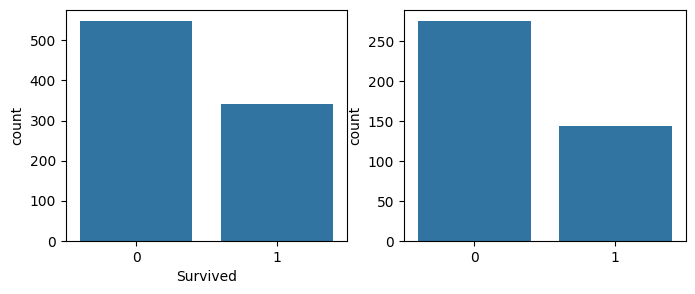

In [59]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
sns.countplot(x=ytrain, ax=axs[0])
sns.countplot(x=pred_test, ax=axs[1])

## [step6] 결과 파일 생성
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

In [60]:
#기존 제출 예제파일 불러오기 
submission = pd.read_csv('./data/sample_submission.csv') 
submission.head(10)

,PassengerId,Survived
0,892,NaN
1,893,NaN
2,894,NaN
3,895,NaN
4,896,NaN
5,897,NaN
6,898,NaN
7,899,NaN
8,900,NaN
9,901,NaN


In [61]:
#예측 데이터 저장하기
submission['Survived'] = pred_test

In [62]:
#확인하기
submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [63]:
#sub.csv  파일로 저장하기 
submission.to_csv('./data/MySubmission.csv', index=False)